In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

In [15]:
# =========================
# CELL 3 — SET PATH DATASET EYEPACS
# =========================
BASE_DIR = "/content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training"
CSV_PATH = os.path.join(BASE_DIR, "trainLabels.csv")
IMG_DIR = os.path.join(BASE_DIR, "train")
OUTPUT_NPZ = os.path.join(BASE_DIR, "EyePACS_dataset_224.npz")

print("BASE_DIR   :", BASE_DIR)
print("CSV_PATH   :", CSV_PATH)
print("IMG_DIR    :", IMG_DIR)
print("OUTPUT_NPZ :", OUTPUT_NPZ)

BASE_DIR   : /content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training
CSV_PATH   : /content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/trainLabels.csv
IMG_DIR    : /content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/train
OUTPUT_NPZ : /content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/EyePACS_dataset_224.npz


In [16]:
# =========================
# CELL 4 — CHECK PATH
# =========================
print("BASE_DIR exists :", os.path.exists(BASE_DIR))
print("CSV_PATH exists :", os.path.exists(CSV_PATH))
print("IMG_DIR exists  :", os.path.exists(IMG_DIR))

if os.path.exists(BASE_DIR):
    print("\nIsi BASE_DIR:")
    print(os.listdir(BASE_DIR))

if os.path.exists(IMG_DIR):
    print("\nContoh isi folder image:")
    print(os.listdir(IMG_DIR)[:10])

BASE_DIR exists : True
CSV_PATH exists : True
IMG_DIR exists  : True

Isi BASE_DIR:
['trainLabels.csv', 'train']

Contoh isi folder image:
['8882_left.jpeg', '8882_right.jpeg', '8883_left.jpeg', '8883_right.jpeg', '8884_left.jpeg', '8884_right.jpeg', '8885_left.jpeg', '8893_left.jpeg', '8893_right.jpeg', '8888_right.jpeg']


In [17]:
# =========================
# CELL 5 — LOAD CSV
# =========================
df = pd.read_csv(CSV_PATH)

print("Shape   :", df.shape)
print("Columns :", df.columns.tolist())
display(df.head())

print("\nDistribusi label:")
print(df["level"].value_counts().sort_index())

Shape   : (35126, 2)
Columns : ['image', 'level']


,image,level
0,10_left,0
1,10_right,0
2,13_left,0
3,13_right,0
4,15_left,1



Distribusi label:
level
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64


In [18]:
# =========================
# CELL 6 — CHECK SAMPLE FILE
# =========================
sample_id = str(df.iloc[0]["image"]).strip()

print("Sample ID dari CSV:", sample_id)

# EyePACS biasanya filename di CSV tanpa ekstensi, sedangkan file aslinya .jpeg
possible_exts = [".jpeg", ".jpg", ".png", ".JPEG", ".JPG", ".PNG"]

for ext in possible_exts:
    sample_path = os.path.join(IMG_DIR, sample_id + ext)
    print((ext, os.path.exists(sample_path), sample_path))

Sample ID dari CSV: 10_left
('.jpeg', True, '/content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/train/10_left.jpeg')
('.jpg', False, '/content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/train/10_left.jpg')
('.png', False, '/content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/train/10_left.png')
('.JPEG', False, '/content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/train/10_left.JPEG')
('.JPG', False, '/content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/train/10_left.JPG')
('.PNG', False, '/content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/train/10_left.PNG')


In [19]:
# =========================
# CELL 7 — CONFIG
# =========================
IMG_SIZE = (224, 224)

# PENTING: jangan normalize sekarang
STORE_AS_UINT8 = True

SAVE_FILENAMES = True

POSSIBLE_EXTS = [".jpeg", ".jpg", ".png", ".JPEG", ".JPG", ".PNG"]

print("IMG_SIZE        :", IMG_SIZE)
print("STORE_AS_UINT8  :", STORE_AS_UINT8)
print("SAVE_FILENAMES  :", SAVE_FILENAMES)

IMG_SIZE        : (224, 224)
STORE_AS_UINT8  : True
SAVE_FILENAMES  : True


In [20]:
# =========================
# CELL 8 — FIND IMAGE FILE
# =========================
def find_image_path(img_dir, img_id, possible_exts):
    img_id = str(img_id).strip()

    # cek langsung kalau ternyata sudah ada ekstensi
    direct_path = os.path.join(img_dir, img_id)
    if os.path.exists(direct_path):
        return direct_path

    # kalau belum ada, tambahkan ekstensi
    for ext in possible_exts:
        candidate = os.path.join(img_dir, img_id + ext)
        if os.path.exists(candidate):
            return candidate

    return None

In [21]:
# =========================
# CELL 9 — LOAD & PREPROCESS IMAGE
# =========================
import cv2

def load_and_preprocess_image(img_path, target_size=(224, 224), store_as_uint8=True):
    img = cv2.imread(img_path)

    if img is None:
        raise ValueError("Image not readable")

    img = cv2.resize(img, target_size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if store_as_uint8:
        return img.astype(np.uint8)
    else:
        return (img / 255.0).astype(np.float32)

In [22]:
# =========================
# CELL 10 — VALIDATE IMAGE MATCHING
# =========================
missing_files = []
found_count = 0

for img_id in tqdm(df["image"], desc="Checking image files"):
    img_path = find_image_path(IMG_DIR, img_id, POSSIBLE_EXTS)
    if img_path is None:
        missing_files.append(str(img_id).strip())
    else:
        found_count += 1

print("Jumlah data CSV     :", len(df))
print("Jumlah file ketemu  :", found_count)
print("Jumlah file missing :", len(missing_files))

if len(missing_files) > 0:
    print("\nContoh missing:")
    print(missing_files[:10])

Checking image files: 100%|██████████| 35126/35126 [00:15<00:00, 2295.92it/s]

Jumlah data CSV     : 35126
Jumlah file ketemu  : 35126
Jumlah file missing : 0


In [23]:
# =========================
# CELL 11 — CONVERT IMAGES TO ARRAY
# =========================
from multiprocessing import Pool, cpu_count

def process_one(args):
    img_id, label = args

    img_id_str = str(img_id).strip()

    img_path = find_image_path(IMG_DIR, img_id_str, POSSIBLE_EXTS)

    if img_path is None:
        return (None, label, img_id_str)

    try:
        img = load_and_preprocess_image(
            img_path,
            target_size=IMG_SIZE,
            store_as_uint8=STORE_AS_UINT8
        )
        return (img, label, img_id_str)

    except Exception:
        return (None, label, img_id_str)


ids = df["image"].values
labels_np = df["level"].values

data = list(zip(ids, labels_np))

NUM_WORKERS = cpu_count()

print("Using CPU cores:", NUM_WORKERS)

with Pool(NUM_WORKERS) as p:
    raw_results = list(tqdm(
        p.imap(process_one, data),
        total=len(data),
        desc="Processing EyePACS (FAST)"
    ))

# Filter valid results and separate failed files
successful_results = []
failed_files = []

for r in raw_results:
    if r[0] is not None: # r[0] is the image array
        successful_results.append(r)
    else:
        failed_files.append(r[2]) # r[2] is the img_id_str

print("Valid results:", len(successful_results))

# unpack successful results
if successful_results:
    images, labels, filenames = zip(*successful_results)
    X = np.array(images, dtype=np.uint8)
    y = np.array(labels, dtype=np.int64)
    filenames = np.array(filenames)
else:
    # Handle case where no images are successfully processed
    X = np.empty((0, IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.uint8)
    y = np.empty((0,), dtype=np.int64)
    filenames = np.array([])

print("X shape :", X.shape)
print("y shape :", y.shape)
print("Failed  :", len(failed_files))

Using CPU cores: 8


Processing EyePACS (FAST): 100%|██████████| 35126/35126 [26:03<00:00, 22.46it/s]


Valid results: 35126
X shape : (35126, 224, 224, 3)
y shape : (35126,)
Failed  : 0


In [24]:
# =========================
# CELL 12 — INSPECT RESULT
# =========================
print("Jumlah image berhasil:", len(X))
print("Jumlah label berhasil:", len(y))
print("Jumlah failed        :", len(failed_files))

if len(failed_files) > 0:
    print("\nContoh file gagal:")
    for item in failed_files[:10]:
        print(item)

if len(X) > 0:
    print("\nX dtype   :", X.dtype)
    print("y dtype   :", y.dtype)
    print("Label unik:", np.unique(y))
    print("Min pixel :", X.min())
    print("Max pixel :", X.max())
else:
    print("\nX kosong. Berarti masih ada masalah di path / nama file / ekstensi.")

Jumlah image berhasil: 35126
Jumlah label berhasil: 35126
Jumlah failed        : 0

X dtype   : uint8
y dtype   : int64
Label unik: [0 1 2 3 4]
Min pixel : 0
Max pixel : 255


In [25]:
# =========================
# CELL 13 — SAVE TO NPZ
# =========================
if len(X) == 0:
    raise ValueError("X kosong, NPZ tidak bisa disimpan.")

np.savez_compressed(
    OUTPUT_NPZ,
    images=X,
    labels=y,
    filenames=filenames
)

print("NPZ saved to:")
print(OUTPUT_NPZ)

NPZ saved to:
/content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/EyePACS_dataset_224.npz


In [26]:
# =========================
# CELL 14 — SANITY CHECK NPZ
# =========================
assert os.path.exists(OUTPUT_NPZ), f"NPZ file tidak ditemukan: {OUTPUT_NPZ}"

data = np.load(OUTPUT_NPZ, allow_pickle=True)
print("Keys in NPZ:", data.files)

for k in data.files:
    arr = data[k]
    try:
        print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")
    except Exception:
        print(f"{k}: type={type(arr)}")

Keys in NPZ: ['images', 'labels', 'filenames']
images: shape=(35126, 224, 224, 3), dtype=uint8
labels: shape=(35126,), dtype=int64
filenames: shape=(35126,), dtype=<U11


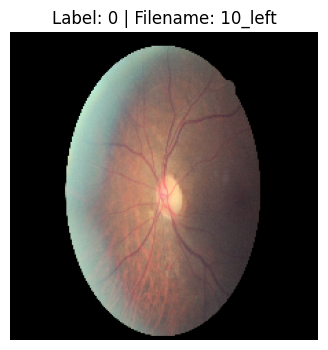

In [27]:
# =========================
# CELL 15 — SHOW SAMPLE
# =========================
idx = 0

plt.figure(figsize=(4, 4))
plt.imshow(X[idx])
plt.title(f"Label: {y[idx]} | Filename: {filenames[idx]}")
plt.axis("off")
plt.show()

In [28]:
# =========================
# CELL 16 — LABEL DISTRIBUTION
# =========================
unique, counts = np.unique(y, return_counts=True)

print("Distribusi label dari NPZ:")
for u, c in zip(unique, counts):
    print(f"Label {u}: {c}")

Distribusi label dari NPZ:
Label 0: 25810
Label 1: 2443
Label 2: 5292
Label 3: 873
Label 4: 708
